In [1]:
days_holding = "3"
top_percentile = "0.95"
bottom_percentile = "0.00"
days_momentum_score = "40"
min_volume = "1_000_000"

In [2]:
days_holding_P = int(days_holding)
top_percentile_P = float(top_percentile)
bottom_percentile_P = (
    float(bottom_percentile) if bottom_percentile != "None" else None
)
days_momentum_score_P = int(days_momentum_score)
min_volume_P = int(min_volume)

print(f"""
days_holding: {days_holding_P}
days_momentum_score: {days_momentum_score_P}
min_volume: {min_volume_P}

top_percentile: {top_percentile_P}
bottom_percentile: {bottom_percentile_P}
""")


days_holding: 3
days_momentum_score: 40
min_volume: 1000000

top_percentile: 0.95
bottom_percentile: 0.0



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1251/1251 [00:15<00:00, 82.48it/s]


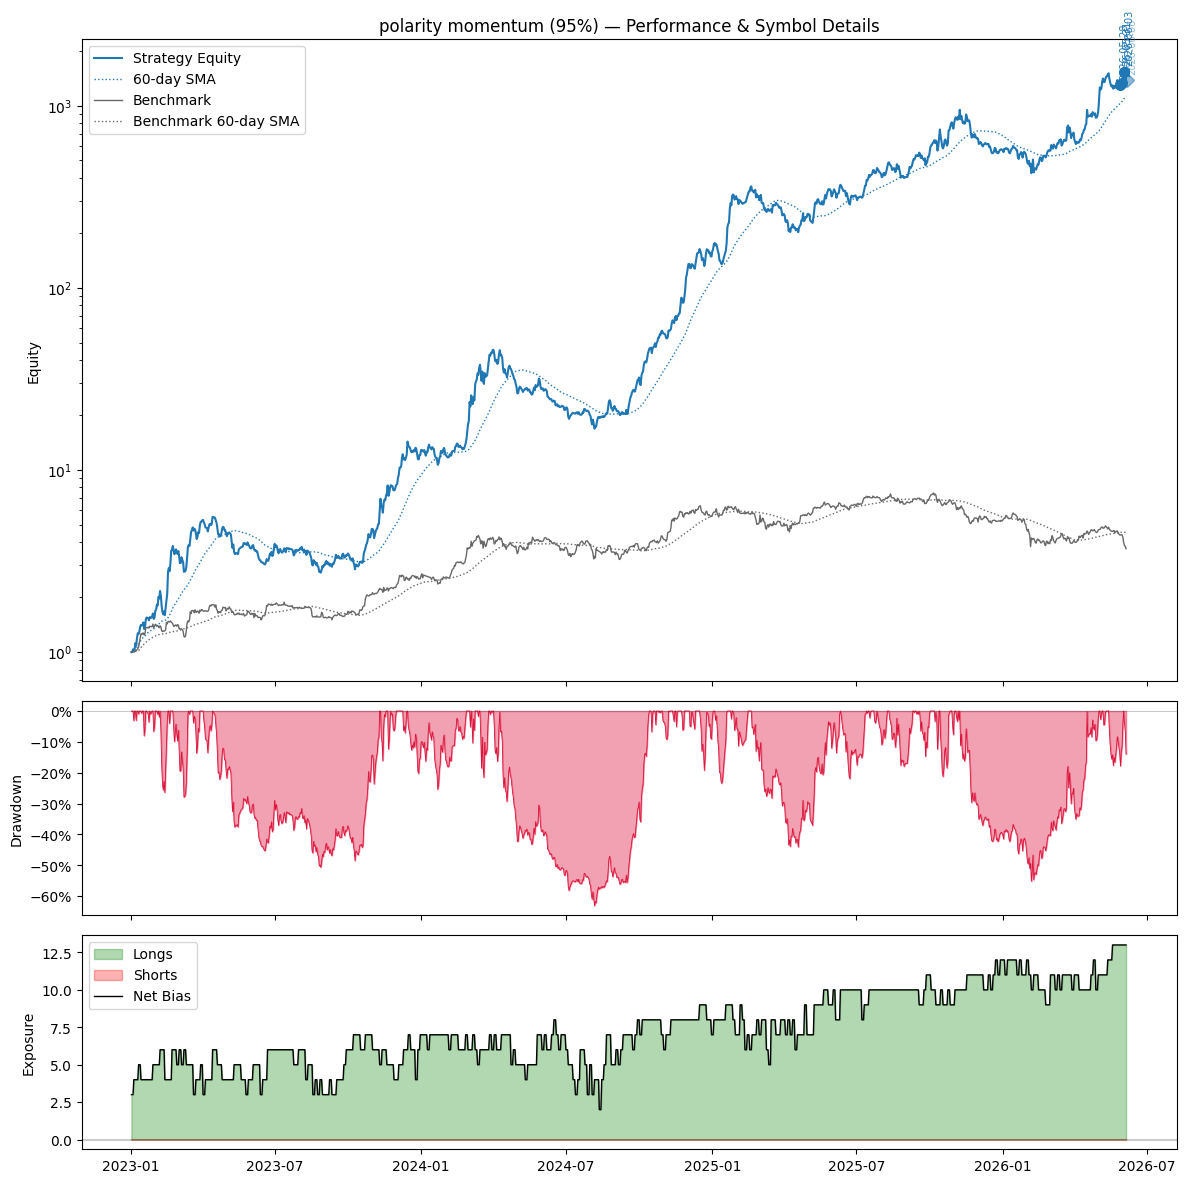

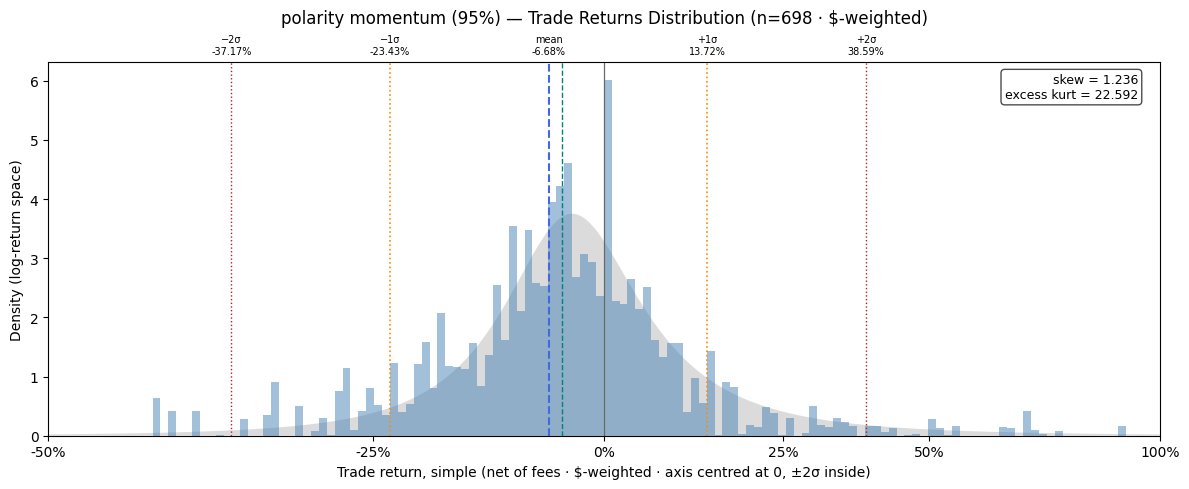

GT(_tbl_data=shape: (2, 14)
┌───────────┬──────────┬──────────┬──────────┬───┬───────────┬───────────┬──────────┬───────────┐
│ Statistic ┆ CAGR     ┆ Sharpe   ┆ Sortino  ┆ … ┆ mae_mean  ┆ mae_stdev ┆ mfe_mean ┆ mfe_stdev │
│ ---       ┆ ---      ┆ ---      ┆ ---      ┆   ┆ ---       ┆ ---       ┆ ---      ┆ ---       │
│ str       ┆ f64      ┆ f64      ┆ f64      ┆   ┆ f64       ┆ f64       ┆ f64      ┆ f64       │
╞═══════════╪══════════╪══════════╪══════════╪═══╪═══════════╪═══════════╪══════════╪═══════════╡
│ Strategy  ┆ 7.394313 ┆ 2.815539 ┆ 5.250977 ┆ … ┆ -0.118111 ┆ 0.142839  ┆ 0.163542 ┆ 0.412172  │
│ Benchmark ┆ 0.470482 ┆ 1.056328 ┆ 1.655836 ┆ … ┆ null      ┆ null      ┆ null     ┆ null      │
└───────────┴──────────┴──────────┴──────────┴───┴───────────┴───────────┴──────────┴───────────┘, _body=<great_tables._gt_data.Body object at 0x3002aa3e0>, _boxhead=Boxhead([ColInfo(var='Statistic', type=<ColInfoTypeEnum.stub: 2>, column_label='Statistic', column_align='left', column_width=None), ColInfo(var='CAGR', type=<ColInfoTypeEnum.default: 1>, column_label='CAGR', column_align='right', column_width=None), ColInfo(var='Max DD', type=<ColInfoTypeEnum.default: 1>, column_label='Max DD', column_align='right', column_width=None), ColInfo(var='Fees', type=<ColInfoTypeEnum.default: 1>, column_label='Fees', column_align='right', column_width=None), ColInfo(var='Sharpe', type=<ColInfoTypeEnum.default: 1>, column_label='Sharpe', column_align='right', column_width=None), ColInfo(var='Sortino', type=<ColInfoTypeEnum.default: 1>, column_label='Sortino', column_align='right', column_width=None), ColInfo(var='IR', type=<ColInfoTypeEnum.default: 1>, column_label='IR', column_align='right', column_width=None), ColInfo(var='Half Kelly', type=<ColInfoTypeEnum.default: 1>, column_label='Half Kelly', column_align='right', column_width=None), ColInfo(var='return_mean', type=<ColInfoTypeEnum.default: 1>, column_label='Mean', column_align='right', column_width=None), ColInfo(var='return_stdev', type=<ColInfoTypeEnum.default: 1>, column_label='St. dev.', column_align='right', column_width=None), ColInfo(var='mae_mean', type=<ColInfoTypeEnum.default: 1>, column_label='Mean', column_align='right', column_width=None), ColInfo(var='mae_stdev', type=<ColInfoTypeEnum.default: 1>, column_label='St. dev.', column_align='right', column_width=None), ColInfo(var='mfe_mean', type=<ColInfoTypeEnum.default: 1>, column_label='Mean', column_align='right', column_width=None), ColInfo(var='mfe_stdev', type=<ColInfoTypeEnum.default: 1>, column_label='St. dev.', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x300b6ec20>, _spanners=Spanners([SpannerInfo(spanner_id='Performance', spanner_level=0, spanner_label='Performance', spanner_units=None, spanner_pattern=None, vars=['CAGR', 'Max DD', 'Fees'], built=None), SpannerInfo(spanner_id='Risk', spanner_level=0, spanner_label='Risk', spanner_units=None, spanner_pattern=None, vars=['Sharpe', 'Sortino', 'IR', 'Half Kelly'], built=None), SpannerInfo(spanner_id='Return', spanner_level=0, spanner_label='Return', spanner_units=None, spanner_pattern=None, vars=['return_mean', 'return_stdev'], built=None), SpannerInfo(spanner_id='Adverse', spanner_level=0, spanner_label='Adverse', spanner_units=None, spanner_pattern=None, vars=['mae_mean', 'mae_stdev'], built=None), SpannerInfo(spanner_id='Favorable', spanner_level=0, spanner_label='Favorable', spanner_units=None, spanner_pattern=None, vars=['mfe_mean', 'mfe_stdev'], built=None)]), _heading=Heading(title='polarity momentum (95%)', subtitle='Strategy Statistics', preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x300b6f6a0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x300b6fd90>, _source_notes=[], _footnotes=[], _styles=[StyleInfo(locname=LocBody(columns=None, rows=None, mask=None), grpname=None, colname='CAGR', rownum=0, colnum=None, styles=[CellStyleFill(color='#FFFFFF'

In [3]:
import datetime as dt
import polars as pl
import scrapbook as sb
import backtest_ng as bt
import functools as fc
import operator

stables = [
    "USDT", "BUSD", "USDC", "PAX", "PAXG", "TUSD", "DAI", "USDP", "UST",
    "FDUSD", "USD1", "XUSD", "USD", "EURC", "EURI", "AEUR", "EUR", "GBP",
    "JPY", "AUD", "CAD", "CHF", "NZD", "KRW", "RLUSD", "USD0", "EURS",
    "USDAI", "USDA", "USDM", "FRXUSD", "APYUSD", "A7A5", "NUSD", "FDIT",
    "SATUSD", "YLDS", "GHO", "BFUSD", "CRVUSD", "GUSD", "USX", "AUSD",
    "USDTB", "APXUSD", "RUSD",
]
credit = [
    "REUSD", "FIGR_HELOC", "USDY", "JAAA", "SAFO", "USYC", "OUSG", "EURSAFO",
    "JTRSY", "USTBL", "USTB", "THBILL", "BUIDL", "ONYC",
]
syms = {
    f'{c.upper()}USDT': c for c
    in pl.read_parquet("polarity/latest-data.parquet")['asset'].unique().to_list()
    if not (c in stables or c in credit)
}
cols = ['kucoin','kraken','htx','binance']

cmcdf = (
    pl.read_parquet('data/dataset/all.parquet')
    .with_columns(
        exchange=pl.coalesce([pl.when(pl.col(c).is_in(syms.keys())).then(pl.lit(c)).otherwise(None) for c in cols]),
        pair=pl.coalesce([pl.when(pl.col(c).is_in(syms.keys())).then(pl.col(c)).otherwise(None) for c in cols]),
    )
    .drop_nulls(subset=['exchange'])
    .with_columns(
        symbol=pl.col('pair').replace_strict(syms, default=None),
    )
    .join(
       pl.read_parquet("polarity/latest-data.parquet")
        .select(
            ts=pl.col('timestamp').dt.replace_time_zone('UTC'),
            symbol=pl.col('asset'),
            price=pl.col('price'),
        ),
        on=['ts','symbol']
    )
    #.select(
    #    ts=pl.col('ts'),
    #    symbol=pl.col('kucoin'),
    #    close=pl.col('close'),
    #    volume=pl.col('volume'),
    #)
    #.with_columns(
    #    age=pl.col("ts") - pl.col("ts").min().over("symbol"),
    #)
    #.drop_nulls(subset=['symbol'])
)

geckodf = (
    pl.read_parquet('metrics.parquet')
    #.filter((pl.col('coingecko_slug').is_in(pl.read_parquet('polarity/lala.parquet')['coingecko_slug'].unique().to_list())))
    .with_columns(symbol=pl.col('coingecko_slug'))
)

# change this to cmcdf for the issue to occur
df = (geckodf
    .with_columns(ts=pl.col("ts").dt.cast_time_unit("us"))
    .sort(["symbol", "ts"])
    .drop_nulls(subset=['volume'])
    .with_columns(**{
        f'mom{n}': pl.col("close").pct_change(n).over("symbol")
        for n in set([days_momentum_score_P])
    })
    .with_columns(
        volume=pl.col('volume').rolling_mean(days_holding_P).over('symbol'),
    )
    .with_columns(
        rank=(
            pl.col(f"mom{days_momentum_score_P}").rank(method="ordinal").over("ts")
            / pl.col(f"mom{days_momentum_score_P}").count().over("ts")
        ),
    )
    .filter((pl.col("ts") > dt.datetime(2023, 1, 1,tzinfo=dt.timezone.utc)))# & (pl.col("ts") <= dt.datetime(2026, 5, 16)))
)

df = (
    pl.read_parquet("polarity/latest-data.parquet")
    .rename(
        {
            "asset": "symbol",
            "price": "close",
            "timestamp":"ts",
        }
    )
    .with_columns(ts=pl.col("ts").dt.cast_time_unit("us").dt.replace_time_zone('UTC'))
    .sort(["symbol", "ts"])
    .with_columns(**{
        f'mom{n}': pl.col("close").pct_change(n).over("symbol")
        for n in set([days_momentum_score_P])
    })
    .with_columns(
        rank=(
            pl.col(f"mom{days_momentum_score_P}").rank(method="ordinal").over("ts")
            / pl.col(f"mom{days_momentum_score_P}").count().over("ts")
        ),
        volume=pl.col('total_volume').rolling_mean(days_holding_P).over('symbol'),
    )
    .sort("ts")
    .filter((pl.col("ts") > dt.datetime(2023, 1, 1,tzinfo=dt.timezone.utc)))# & (pl.col("ts") <= dt.datetime(2026, 5, 16)))
    .drop_nulls(['volume'])
)

class Alpha(bt.AlphaModel):
    def __init__(self, long_expr: pl.Expr, short_expr: pl.Expr):
        self.long_expr = long_expr
        self.short_expr = short_expr

    def __call__(self, history: pl.DataFrame, u: bt.Universe) -> list[bt.Signal]:
        today = u.df()["ts"].max()
        dfnow = u.df().filter(pl.col("ts") == today)
        l = dfnow.filter(self.long_expr)
        s = dfnow.filter(self.short_expr)

        return [
            bt.Signal(symbol=r['symbol'], bullish=True, confidence=r['rank'])
            for r in l.iter_rows(named=True)
        ] + [
            bt.Signal(symbol=r['symbol'], bullish=False, confidence=1-r['rank'])
            for r in s.iter_rows(named=True)
        ]

test = bt.Backtest(
    title="polarity momentum (95%)",
    universe=bt.Manual(df),
    alpha=Alpha(
        long_expr=(pl.col("rank") >= top_percentile_P) & (pl.col('volume') > min_volume_P),
        short_expr=(
            (pl.col("rank") <= bottom_percentile_P) & (pl.col('volume') > min_volume_P)
            if bottom_percentile_P is not None
            else pl.lit(False)
        ),
    ),
    benchmark="btc",
    period=days_holding_P,
)

test.run()
res = test.report(plot=True)

In [6]:
print(
    test.live(equity=10_000)
    .select(
        pl.col('entry_ts').dt.strftime('%Y-%m-%d'),
        pl.col('symbol').str.to_uppercase(),
        pl.lit(''),
        pl.col('entry_price'),
        pl.col('shares'),
        (pl.col('entry_price') * pl.col('shares')).alias('cost'),
    )
    .sort('symbol')
    .write_csv()
)

entry_ts,symbol,literal,entry_price,shares,cost
2026-06-05,9BIT,"",0.04571313607322531,18229.625112537964,833.3333333333331
2026-06-05,B,"",0.23420194946877565,3558.182735982884,833.3333333333333
2026-06-05,BEAT,"",1.6374943164322073,508.90761877513575,833.3333333333333
2026-06-05,H,"",0.5599317902775296,1488.2765147524353,833.3333333333333
2026-06-05,HOME,"",0.050400855632363184,16534.110837559605,833.3333333333331
2026-06-05,LAB,"",11.179522535435924,74.54104866213224,833.3333333333331
2026-06-05,RAIN,"",0.013402418031619142,62177.83472857834,833.3333333333333
2026-06-05,TAG,"",0.001066396731626775,781447.7563730842,833.3333333333334
2026-06-05,UB,"",0.10666929115108487,7812.307781749592,833.3333333333333
2026-06-05,VVV,"",15.090297667860614,55.22312095328447,833.3333333333333
2026-06-05,WLD,"",0.508981257781648,1637.257405047381,833.3333333333333
2026-06-05,币安人生,"",0.6620690342197545,1258.6804249430168,833.3333333333333



In [5]:
print(test.positions.filter(pl.col('ts') == dt.datetime(2026,5,13)).write_csv())

SchemaError: could not evaluate comparison between series 'ts' of dtype: Datetime('μs', 'UTC') and series 'literal' of dtype: Datetime('μs')